# Retail Sales Exploratory Data Analysis

**Goal:** Understand sales patterns, customer behavior, trends, and anomalies to generate business insights and prepare features for machine learning.

**Import Libraries**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
!pip install holidays

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

**Loading Dataset**

In [51]:
# Loading Excel file
df = pd.read_excel("retail_sales.xlsx")

# Saving it as CSV
df.to_csv("retail_sales.csv", index=False)

#EDA

In [52]:

df.head(10).T

,0,1,2,3,4,5,6,7,8,9
Transaction ID,1,2,3,4,5,6,7,8,9,10
Date,2023-11-24 00:00:00,2023-02-27 00:00:00,2023-01-13 00:00:00,2023-05-21 00:00:00,2023-05-06 00:00:00,2023-04-25 00:00:00,2023-03-13 00:00:00,2023-02-22 00:00:00,2023-12-13 00:00:00,2023-10-07 00:00:00
Customer ID,CUST001,CUST002,CUST003,CUST004,CUST005,CUST006,CUST007,CUST008,CUST009,CUST010
Gender,Male,Female,Male,Male,Male,Female,Male,Male,Male,Female
Age,34,26,50,37,30,45,46,30,63,52
Product Category,Beauty,Clothing,Electronics,Clothing,Beauty,Beauty,Clothing,Electronics,Electronics,Clothing
Quantity,3,2,1,1,2,1,2,4,2,4
Price per Unit,50,500,30,500,50,30,25,25,300,50
Total Amount,150,1000,30,500,100,30,50,100,600,200


Df.head displays the first 10 transactions.  It confirms that:

1.   Each row represents a unique transaction.
2.   Dates span across 2023, supporting time-based analysis.
3.   Customer demographics (age and gender) vary.
4.   Product categories include Beauty, Clothing, and Electronics.
5.   Total Amount correctly equals Quantity × Price per Unit e.g., 3 × 50 = 150.

Overall, the sample confirms data consistency, realistic values, and structural readiness for further analysis.

In [39]:
print("Shape:", df.shape) # shape and info
df.info()

Shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


The dataframe has a total of 9 columns with 1000 rows.
Data type: integers and object.

In [53]:
df.isnull().sum()  #missing values

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


No missing values in the dataframe.

In [54]:
df.duplicated().sum() #duplicate rows

np.int64(0)

There are no duplicated rows, each row is unique

In [55]:
df.describe().T #descriptive statistics

,count,mean,min,25%,50%,75%,max,std
Transaction ID,1000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Date,1000,2023-07-03 00:25:55.200000256,2023-01-01 00:00:00,2023-04-08 00:00:00,2023-06-29 12:00:00,2023-10-04 00:00:00,2024-01-01 00:00:00,NaN
Age,1000.0,41.392,18.0,29.0,42.0,53.0,64.0,13.68143
Quantity,1000.0,2.514,1.0,1.0,3.0,4.0,4.0,1.132734
Price per Unit,1000.0,179.89,25.0,30.0,50.0,300.0,500.0,189.681356
Total Amount,1000.0,456.0,25.0,60.0,135.0,900.0,2000.0,559.997632


The descriptive statistics summarize distribution, central tendency, and variability across 1,000 transactions.

**Age**: Customers range from 18 to 64 years, with a mean of about 41 years and a standard deviation of 13.7, This implies that most customers fall roughly between 27 and 55 years, hence a moderately diverse age distribution without extreme concentration in one age group.

**Quantity**: Customer purchases range from 1 to 4 units, with a median of 3, and a low standard deviation of 1.13. This means purchasing quantities do not vary much. with small-volume retail transactions.

**Price per Unit**: Prices vary significantly (25–500), with a mean of 180 and standard deviation of 189.7. This confirms that the dataset contains products from different price tiers, across multiple categories and showing substantial variation across product categories.

**Total Amount**: Transaction values range from 25 to 2000, with a mean of 456 and a median of 135, indicating right-skewness due to some high-value purchases.


# Data Cleaning

In [56]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Convert ID to string
df['Customer ID'] = df['Customer ID'].astype(str)

# Convert categorical variables
df['Gender'] = df['Gender'].astype('category')
df['Product Category'] = df['Product Category'].astype('category')

Conversion of date, gender, customer ID and product category from object type into  date time, category and string.

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   category      
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   category      
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(5), object(1)
memory usage: 57.0+ KB


# Outlier Detection

**Box Plot**

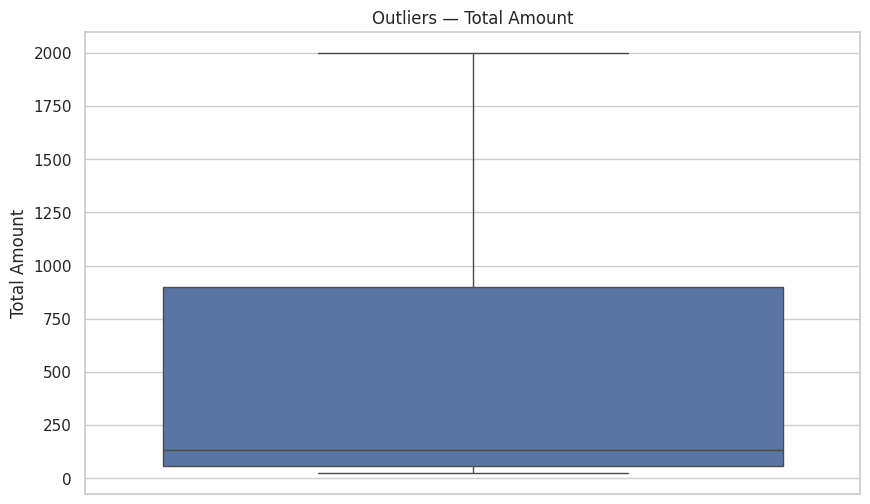

In [58]:
sns.boxplot(df['Total Amount']) #box plot
plt.title("Outliers — Total Amount")
plt.show()

The median transaction value lies close to the lower end of the box, indicating that most purchases are relatively small.

The interquartile range (IQR) the box spans a wide range, showing substantial variability in transaction amounts.

The upper whisker extends far upward (toward 2000), meaning some transactions are much larger than typical ones.

There are no individual points outside the whiskers, which confirms that no  outliers were detected.

**Z Score**

In [59]:
df['Z'] = np.abs(stats.zscore(df['Total Amount']))
outliers = df[df['Z'] > 3]
print("Outliers:", len(outliers))

Outliers: 0


No outliers were detected.

Dropping Transaction ID

In [63]:
df = df.drop(columns=['Transaction ID'])
df = df.drop(columns=['Z'])

# Correlation Analysis (Raw Data)

Purpose  is to understand original relationships before feature engineering.

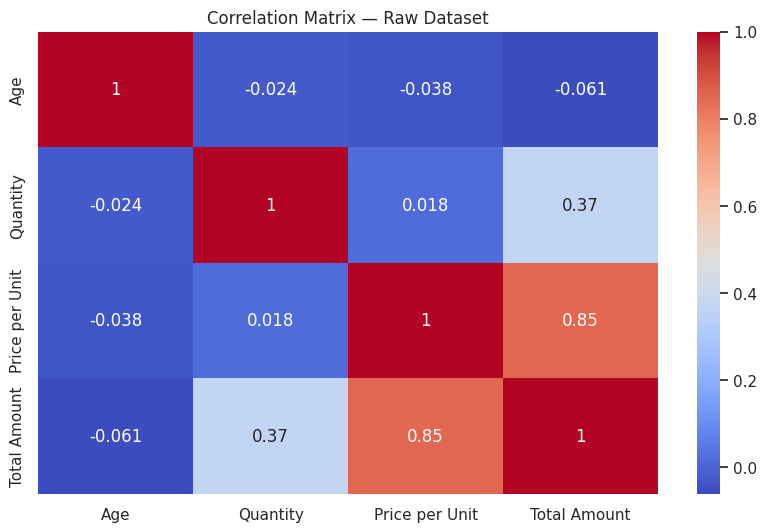

In [64]:
corr_raw = df.corr(numeric_only=True)

sns.heatmap(corr_raw, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix — Raw Dataset")
plt.show()

The correlation matrix shows that Price per Unit has a strong positive relationship with Total Amount (r ≈ 0.85 ,this indicates that transaction value is primarily driven by product price rather than other variables.

Quantity exhibits a moderate positive correlation with Total Amount (r ≈ 0.37), suggesting that purchase volume contributes to sales but is less influential than pricing.

From a business perspective, this implies that pricing strategy and product mix are the most critical factors affecting revenue, while demographic variables such as age have minimal impact on spending behavior.

**Pair Plot**

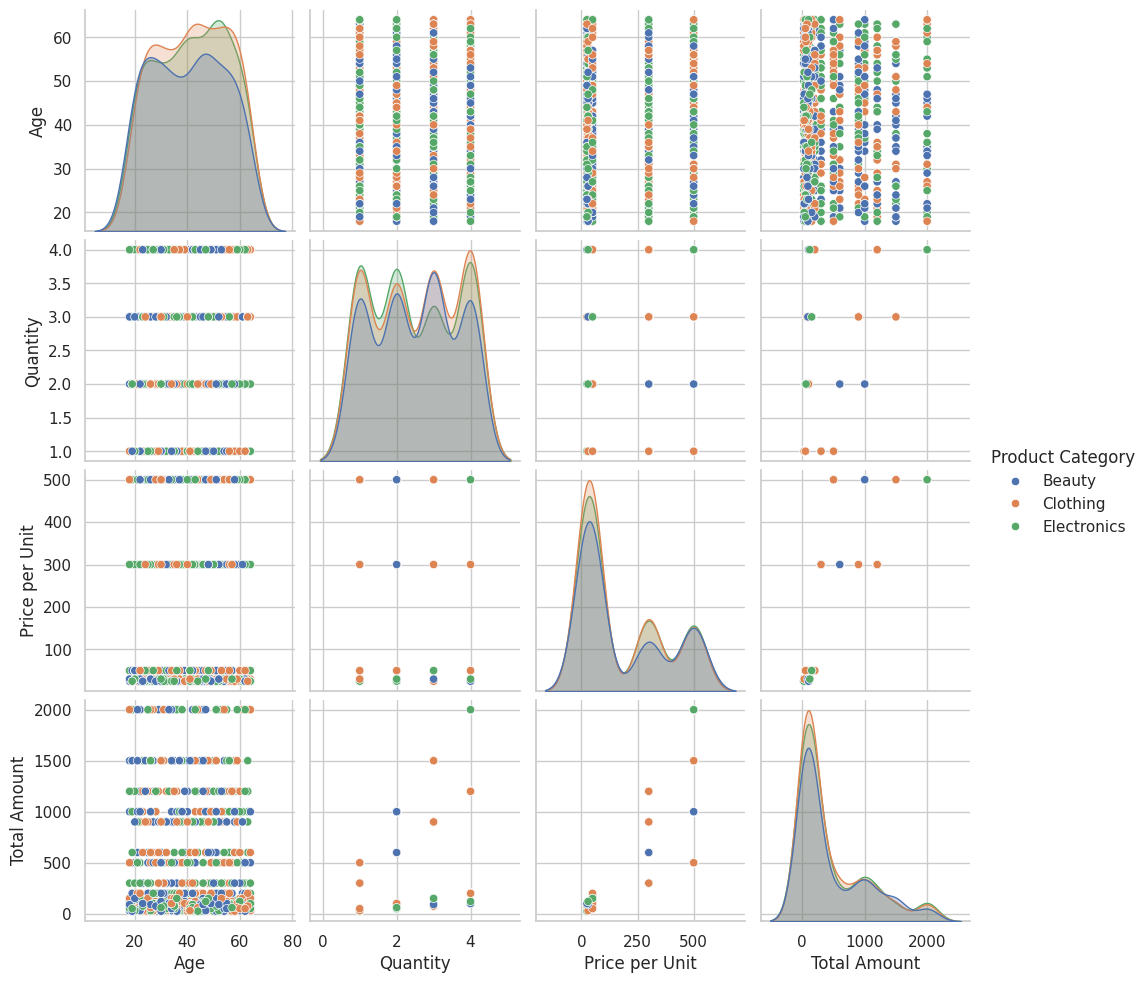

In [65]:
sns.pairplot(
    df,
    vars=['Age','Quantity','Price per Unit','Total Amount'],
    hue='Product Category',
    diag_kind='kde'
)
plt.show()

The pair plot confirms that price shows the strongest relationship with total transaction value, while age and quantity exhibit weaker associations.

**Price Vs Total sales**

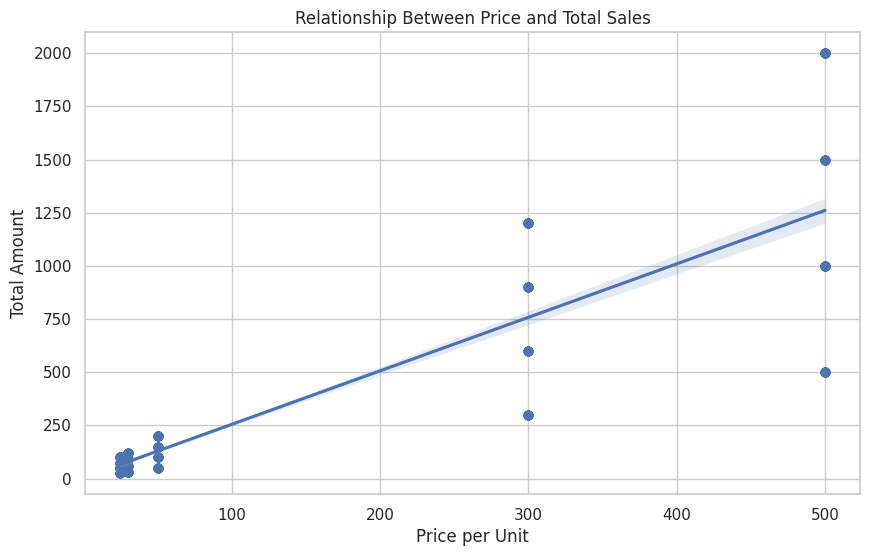

In [66]:

sns.regplot(x='Price per Unit', y='Total Amount', data=df, scatter_kws={'alpha':0.6})

plt.title("Relationship Between Price and Total Sales")
plt.show()

The upward-sloping regression line indicates a positive linear relationship:
as Price per Unit increases, Total Amount tends to increase.

This matches the mathematical structure of the data:

Total Amount = Price per Unit × Quantity

Since Total Amount is partly calculated from price,
a strong positive association is expected rather than coincidental.


# Feature Engineering

In [72]:
# Time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

# Holiday feature
import holidays
us_holidays = holidays.US(years=df['Year'].unique())
df['Is_Holiday'] = df['Date'].isin(us_holidays)


/tmp/ipython-input-169/1560858203.py:11: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['Is_Holiday'] = df['Date'].isin(us_holidays)


In [73]:
df.head().T

,0,1,2,3,4
Date,2023-11-24 00:00:00,2023-02-27 00:00:00,2023-01-13 00:00:00,2023-05-21 00:00:00,2023-05-06 00:00:00
Customer ID,CUST001,CUST002,CUST003,CUST004,CUST005
Gender,Male,Female,Male,Male,Male
Age,34,26,50,37,30
Product Category,Beauty,Clothing,Electronics,Clothing,Beauty
Quantity,3,2,1,1,2
Price per Unit,50,500,30,500,50
Total Amount,150,1000,30,500,100
Year,2023,2023,2023,2023,2023
Month,11,2,1,5,5


We did feature engineering on Date to time-based features namely (Year, Month, Day, DayOfWeek, and Quarter) to enable temporal pattern analysis.
These engineered features allow the identification of seasonal trends, daily purchasing behaviors, and periodic sales fluctuations that would not be observable from the original date column alone.


**Key:**


---


Month → 1=Jan, 2=Feb, ..., 12=Dec  
Quarter → 1=Jan–Mar, 2=Apr–Jun, 3=Jul–Sep, 4=Oct–Dec  
DayOfWeek → 0=Mon, 1=Tue, …, 6=Sun

**Time-Series Enhancement**

In [16]:
df = df.sort_values('Date')   #Rolling Sales Average
df['Rolling_7Day_Sales'] = df['Total Amount'].rolling(7).mean()

In [17]:
df.head(20).T

,521,179,558,302,978,162,420,609,682,230,31,390,366,431,149,844,920,796,290,906
Transaction ID,522,180,559,303,979,163,421,610,683,231,32,391,367,432,150,845,921,797,291,907
Date,2023-01-01 00:00:00,2023-01-01 00:00:00,2023-01-01 00:00:00,2023-01-02 00:00:00,2023-01-02 00:00:00,2023-01-02 00:00:00,2023-01-02 00:00:00,2023-01-03 00:00:00,2023-01-04 00:00:00,2023-01-04 00:00:00,2023-01-04 00:00:00,2023-01-05 00:00:00,2023-01-05 00:00:00,2023-01-05 00:00:00,2023-01-06 00:00:00,2023-01-06 00:00:00,2023-01-07 00:00:00,2023-01-07 00:00:00,2023-01-08 00:00:00,2023-01-08 00:00:00
Customer ID,CUST522,CUST180,CUST559,CUST303,CUST979,CUST163,CUST421,CUST610,CUST683,CUST231,CUST032,CUST391,CUST367,CUST432,CUST150,CUST845,CUST921,CUST797,CUST291,CUST907
Gender,Male,Male,Female,Male,Female,Female,Female,Female,Male,Female,Male,Male,Female,Female,Female,Male,Male,Male,Male,Female
Age,46,41,40,19,19,64,37,26,38,23,30,19,57,60,58,54,51,40,60,45
Product Category,Beauty,Clothing,Clothing,Electronics,Beauty,Clothing,Clothing,Beauty,Beauty,Clothing,Beauty,Beauty,Electronics,Electronics,Electronics,Clothing,Electronics,Clothing,Clothing,Electronics
Quantity,3,3,4,3,1,3,3,2,2,3,3,2,1,2,4,1,3,3,2,1
Price per Unit,500,300,300,30,25,50,500,300,500,50,30,25,50,500,30,500,25,25,300,25
Total Amount,1500,900,1200,90,25,150,1500,600,1000,150,90,50,50,1000,120,500,75,75,600,25
Year,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023


Sorting the dataset by date ensures transactions are arranged chronologically, which is essential for time-series analysis and accurate rolling calculations.

In [69]:
# Customer Metrics
customer_total_amount = df.groupby('Customer ID')['Total Amount'].sum()
customer_num_transactions = df.groupby('Customer ID')['Total Amount'].count() # Count total amount as number of transactions
customer_total_quantity = df.groupby('Customer ID')['Quantity'].sum()

customer_metrics = pd.DataFrame({
    'Total Amount': customer_total_amount,
    'Num_Transactions': customer_num_transactions,
    'Quantity': customer_total_quantity
})

customer_metrics.head()

,Total Amount,Num_Transactions,Quantity
Customer ID,,,
CUST001,150,1,3
CUST002,1000,1,2
CUST003,30,1,1
CUST004,500,1,1
CUST005,100,1,2


In [70]:
customer_metrics.tail()

,Total Amount,Num_Transactions,Quantity
Customer ID,,,
CUST995,30,1,1
CUST996,50,1,1
CUST997,90,1,3
CUST998,100,1,4
CUST999,150,1,3


The customer-level aggregation summarizes purchasing behavior by computing total spending, transaction frequency, and total quantity per customer.
The output indicates that each customer currently has one transaction, as reflected by Num_Transactions = 1, suggesting no repeat purchase behavior in this dataset sample.
From a business perspective, this structure enables customer segmentation based on spending value and purchase volume, which supports targeted marketing, loyalty program design, and lifetime value analysis.

# Correlation Analysis (After Feature Engineering)

Correlation was first computed on raw variables to understand baseline relationships, then recomputed after feature engineering to evaluate the predictive usefulness of newly created variables and detect multicollinearity.

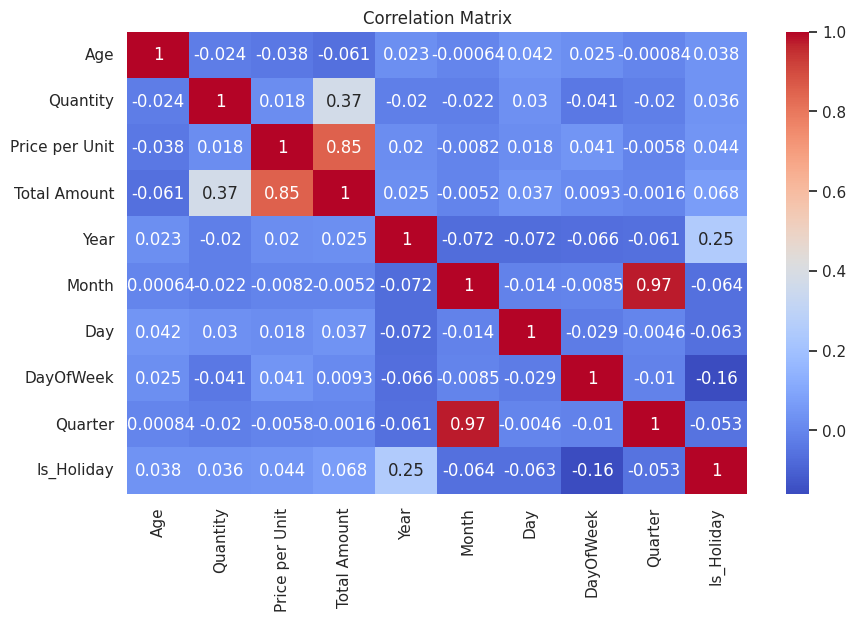

In [75]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix after feature engineering shows that Price per Unit remains the strongest predictor of Total Amount (r ≈ 0.85), confirming that pricing continues to be the primary driver of transaction value even after adding temporal features.


The correlation matrix indicates an extremely strong positive correlation between Month and Quarter (r ≈ 0.97), which is expected because quarters are directly derived from months.
This indicates multicollinearity, meaning both variables capture essentially the same temporal information.

# Exploratory Visual Analysis

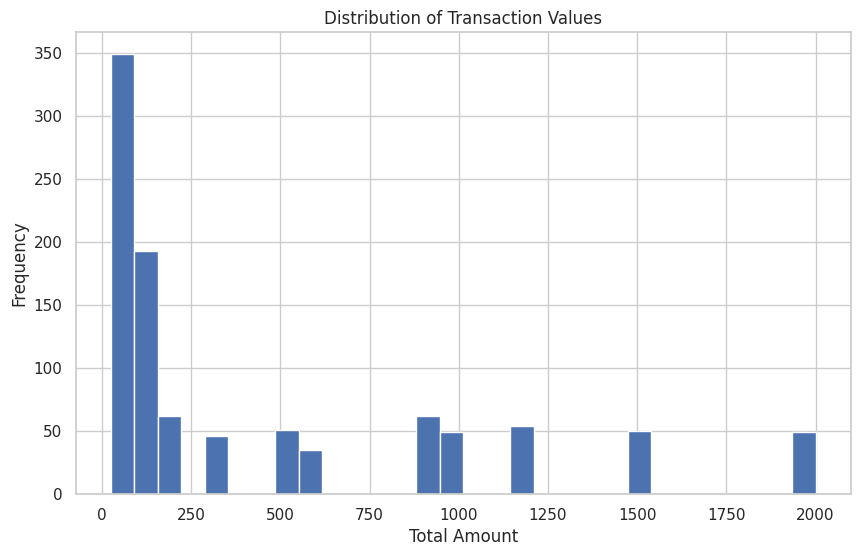

In [76]:
plt.hist(df['Total Amount'], bins=30)
plt.title("Distribution of Transaction Values")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

The distribution is strongly right-skewed, since most transactions occur at low total amounts while a small number of transactions occur at very high values.

**Monthly Trend**

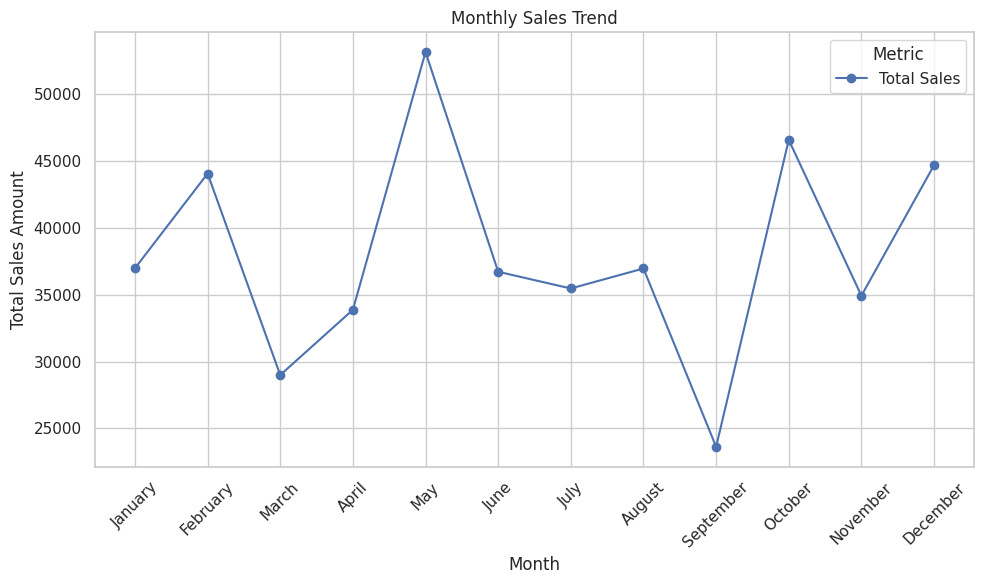

In [22]:

# Monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Converting month numbers into names
month_labels = [calendar.month_name[m] for m in monthly_sales.index]

# Plot
plt.figure()
plt.plot(month_labels, monthly_sales.values, marker='o', label='Total Sales')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")

plt.legend(title="Metric")   # adding legend
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The monthly sales trend shows clear variability across the year, with revenue ranging from approximately 23,500 in September to about 53,000 in May, indicating a spread of nearly 29,500 units.
The average monthly revenue appears to lie around the mid-range (~37,000–40,000), suggesting moderate overall stability despite noticeable peaks and dips.

**Daily Pattern**

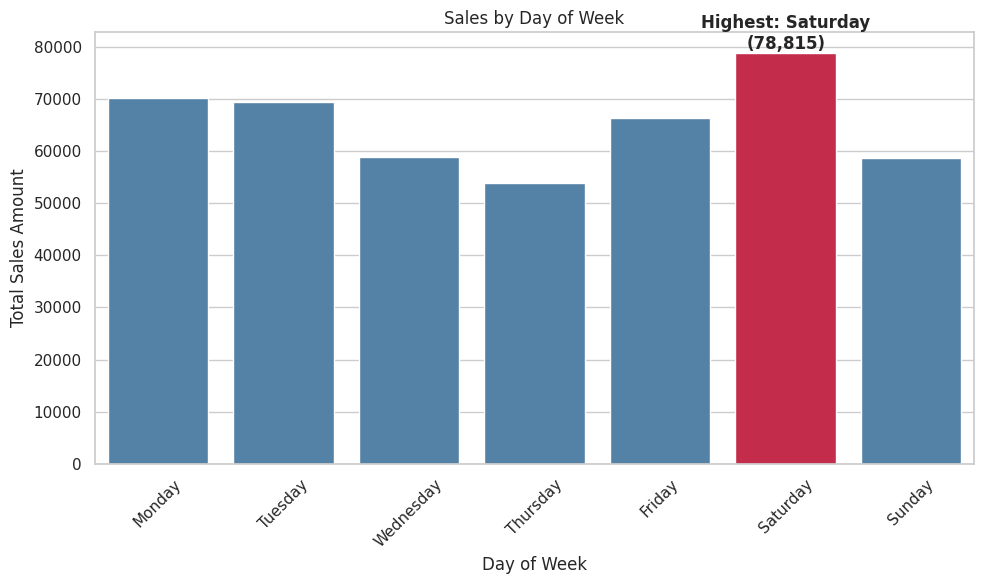

In [27]:
#Finding highest-performing day
dow_sales = df.groupby('DayOfWeek')['Total Amount'].sum()
max_day_num = dow_sales.idxmax() # Get the numeric day of week
max_value = dow_sales.max()

# Map DayOfWeek numbers to names
day_names = [calendar.day_name[i] for i in range(7)]
dow_sales_named = dow_sales.rename(index=lambda x: day_names[x])
max_day_name = day_names[max_day_num]

# Plotting with hue assigned
plt.figure()
sns.barplot(
    x=dow_sales_named.index,
    y=dow_sales_named.values,
    hue=dow_sales_named.index,
    palette=['crimson' if day == max_day_name else 'steelblue' for day in dow_sales_named.index],
    legend=False
)

plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales Amount")

# Annotation
plt.text(
    x=list(dow_sales_named.index).index(max_day_name),
    y=max_value,
    s=f"Highest: {max_day_name}\n({max_value:,.0f})",
    ha='center',
    va='bottom',
    fontweight='bold'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows noticeable variation in total sales across days of the week, with values ranging from approximately 54,000 Thursday to about 78,815 Saturday, giving a difference of roughly 24,500 units.
The average daily revenue appears to fall near 65,000, indicating moderate consistency despite identifiable peaks and troughs.

From a business perspective, the strong performance on Saturday suggests a high-demand period, while lower sales on Thursday indicate slower activity, implying that staffing, promotions, and inventory allocation should be adjusted to align with weekly demand patterns.

**Revenue Comparison Bar** (Holiday Vs Non Holiday)

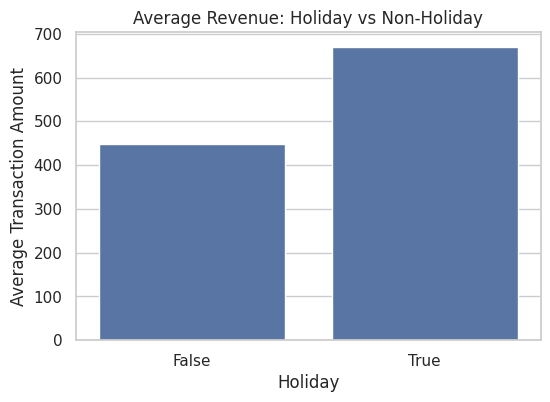

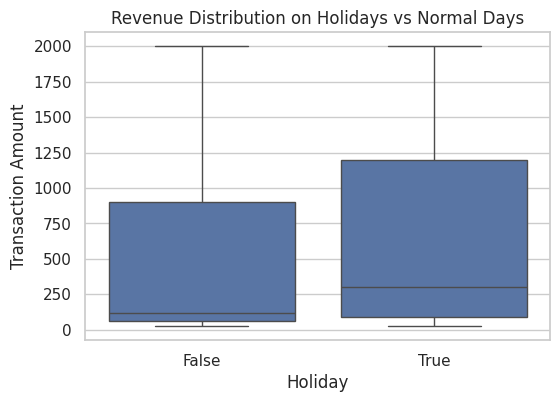

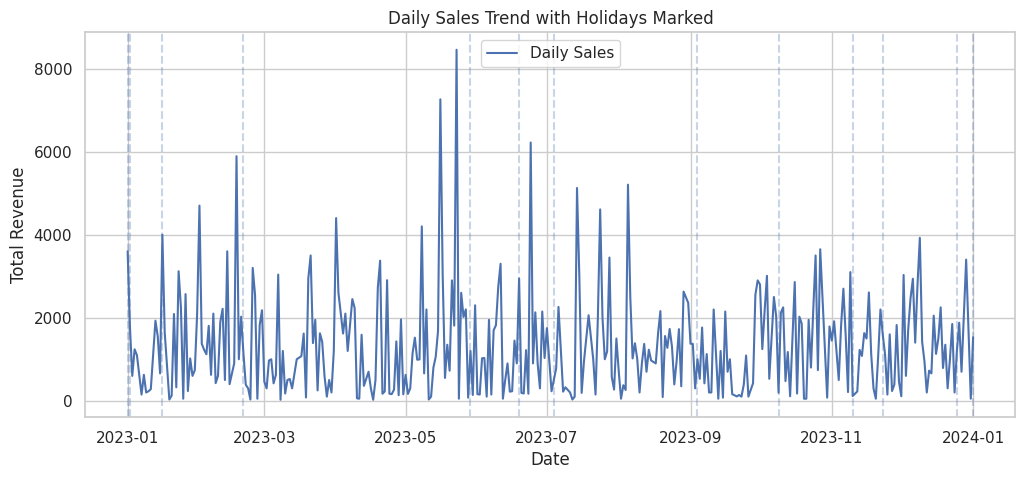

In [ ]:
# =========================
# 1. Revenue Comparison Bar
# =========================
holiday_summary = df.groupby('Is_Holiday')['Total Amount'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=holiday_summary, x='Is_Holiday', y='Total Amount')
plt.title("Average Revenue: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Transaction Amount")
plt.show()


# =========================
# 2. Distribution Comparison
# =========================
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Is_Holiday', y='Total Amount')
plt.title("Revenue Distribution on Holidays vs Normal Days")
plt.xlabel("Holiday")
plt.ylabel("Transaction Amount")
plt.show()


# =========================
# 3. Time Trend Highlighting Holidays
# =========================
daily_sales = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values, label='Daily Sales')

# highlight holidays
holiday_dates = df[df['Is_Holiday'] == True]['Date'].unique()
for h in holiday_dates:
    plt.axvline(h, linestyle='--', alpha=0.3)

plt.title("Daily Sales Trend with Holidays Marked")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.legend()
plt.show()

Average transaction value is approximately 49% higher on holidays than on non-holiday days, indicating that holidays significantly boost customer spending and represent key revenue opportunities.

**Time Series Decomposition**

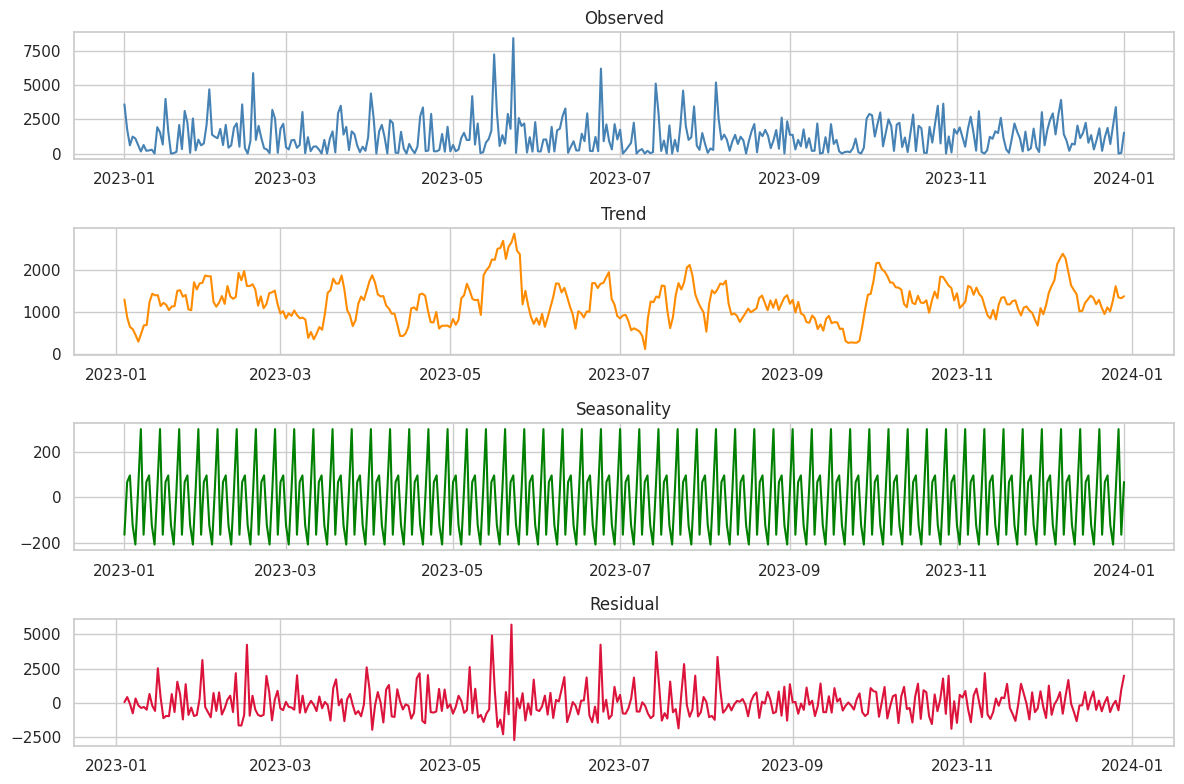

In [33]:
plt.figure(figsize=(12,8))

plt.subplot(411)
plt.plot(decomposition.observed, color='steelblue')
plt.title("Observed")

plt.subplot(412)
plt.plot(decomposition.trend, color='darkorange')
plt.title("Trend")

plt.subplot(413)
plt.plot(decomposition.seasonal, color='green')
plt.title("Seasonality")

plt.subplot(414)
plt.plot(decomposition.resid, color='crimson')
plt.title("Residual")

plt.tight_layout()
plt.show()

1. Observed vs Trend: The observed series shows sharp daily fluctuations, while the trend line reveals a smoother underlying pattern indicating gradual changes in overall sales levels across the year.

2. Seasonality: The repeating wave pattern in the seasonal component indicates consistent periodic behavior, meaning sales systematically rise and fall at regular intervals rather than randomly.

3. Residuals: The residual plot centers around zero with occasional spikes, showing that most variation is explained by trend + seasonality, with only a few unusual days representing unexpected events or anomalies.

**Seasonality Strength**

In [86]:
seasonal_strength = np.var(decomposition.seasonal) / np.var(decomposition.observed)

print("Seasonality Strength:", round(seasonal_strength,3))

Seasonality Strength: 0.018


A seasonality strength of 0.018 means that seasonal patterns  only explain about 1.8% of the total variation in sales.
This meanss that sales are not strongly driven by recurring seasonal cycles, but more by other factors like pricing or random fluctuations.

**Anomaly Detection (Z-Score Method)**

In [87]:
daily_sales = df.groupby('Date')['Total Amount'].sum()

z = (daily_sales - daily_sales.mean()) / daily_sales.std()

anomalies = daily_sales[np.abs(z) > 3]

print("Anomaly Days:")
print(anomalies)

Anomaly Days:
Date
2023-02-17    5890
2023-05-16    7260
2023-05-23    8455
2023-06-24    6220
2023-07-14    5125
2023-08-05    5205
Name: Total Amount, dtype: int64


The Z-score method flagged these dates because their daily sales are more than 3 standard deviations from the mean, meaning they are statistically unusual.
These spikes  are more likely representing  special events, promotions, holidays, or data anomalies that significantly boosted revenue compared to normal days.

**Root Cause Analysis of Anomalies**

In [88]:
df[df['Date'].isin(anomalies.index)].groupby('Product Category')['Total Amount'].sum()

/tmp/ipython-input-169/3655018633.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['Date'].isin(anomalies.index)].groupby('Product Category')['Total Amount'].sum()


,Total Amount
Product Category,
Beauty,10945
Clothing,6240
Electronics,20970


On the anomaly days, Electronics generated the highest revenue (20,970), followed by Beauty (10,945) and Clothing (6,240).

This shows that the unusual sales spikes were primarily driven by Electronics purchases, suggesting promotions, product launches, or high-ticket transactions in that category.

# Product Category Analysis

In [ ]:
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

/tmp/ipython-input-276/2039501992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)


,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


The table shows total units sold by product category, with Clothing recording the highest quantity (894 units), followed by Electronics (849) and Beauty (771).
The relatively small difference between categories (maximum gap ≈123 units) indicates fairly balanced product demand across segments rather than dominance by a single category.
From a business perspective, this suggests that while Clothing is the highest-volume category and may require greater inventory allocation, overall demand is diversified, reducing reliance on any single product line and supporting stable revenue streams.

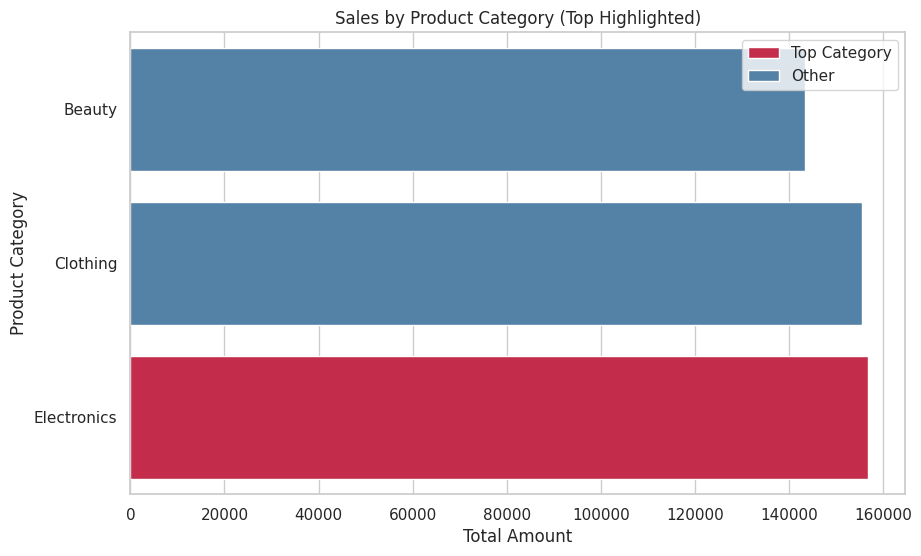

In [ ]:
# Aggregating sales
category_sales = (
    df.groupby('Product Category', observed=True)['Total Amount']
      .sum()
      .sort_values(ascending=False)
)

# Identifing largest category
max_cat = category_sales.idxmax()

# Creating a color flag column
plot_df = category_sales.reset_index()
plot_df['Highlight'] = plot_df['Product Category'].apply(
    lambda x: 'Top Category' if x == max_cat else 'Other'
)

# Plotting
plt.figure()
sns.barplot(
    data=plot_df,
    x='Total Amount',
    y='Product Category',
    hue='Highlight',
    dodge=False,
    palette={'Top Category': 'crimson', 'Other': 'steelblue'}
)

plt.title("Sales by Product Category (Top Highlighted)")
plt.legend(title="")
plt.show()

The bar chart shows that total sales are relatively balanced across product categories, with Electronics generating the highest revenue (≈156,000), followed closely by Clothing (≈154,000), while Beauty records slightly lower sales (≈142,000).
The difference between the highest and lowest category is about 14,000 units, indicating only moderate variation and suggesting no single category dominates overall revenue.
From a business perspective, this balanced distribution reflects a diversified product portfolio, which reduces financial risk and indicates that revenue is supported by multiple product lines rather than reliance on one category.

# Demographic Analysis

**Spending by gender**

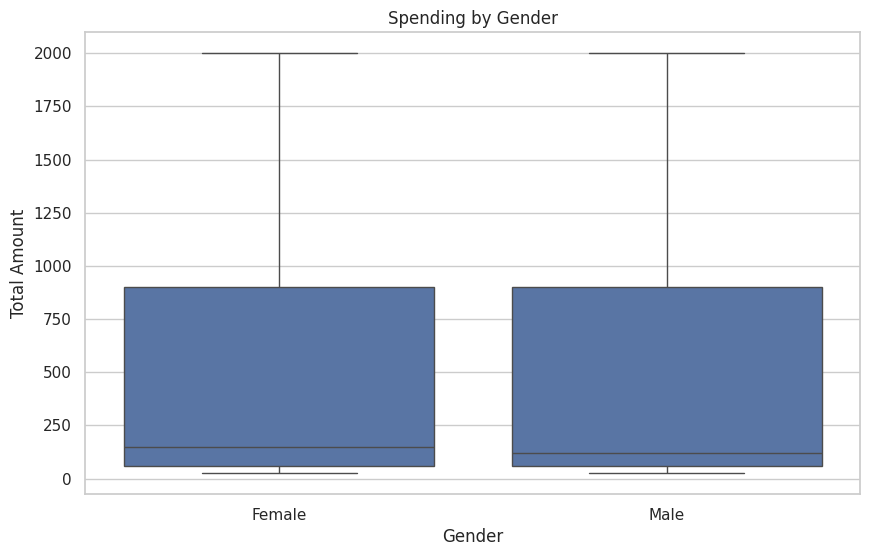

In [ ]:
sns.boxplot(x='Gender', y='Total Amount', data=df)
plt.title("Spending by Gender")
plt.show()

The boxplot shows that spending distributions for male and female customers are highly similar, with comparable medians, interquartile ranges, and overall spread of transaction values.
Both groups exhibit wide variability, with transaction amounts ranging from low values to nearly 2000, indicating substantial differences in individual purchasing behavior regardless of gender.
From a business perspective, this suggests that gender is not a strong determinant of spending patterns, implying that marketing and pricing strategies should focus more on behavioral or product-based segmentation rather than demographic targeting.

**Purchase by gender and category**

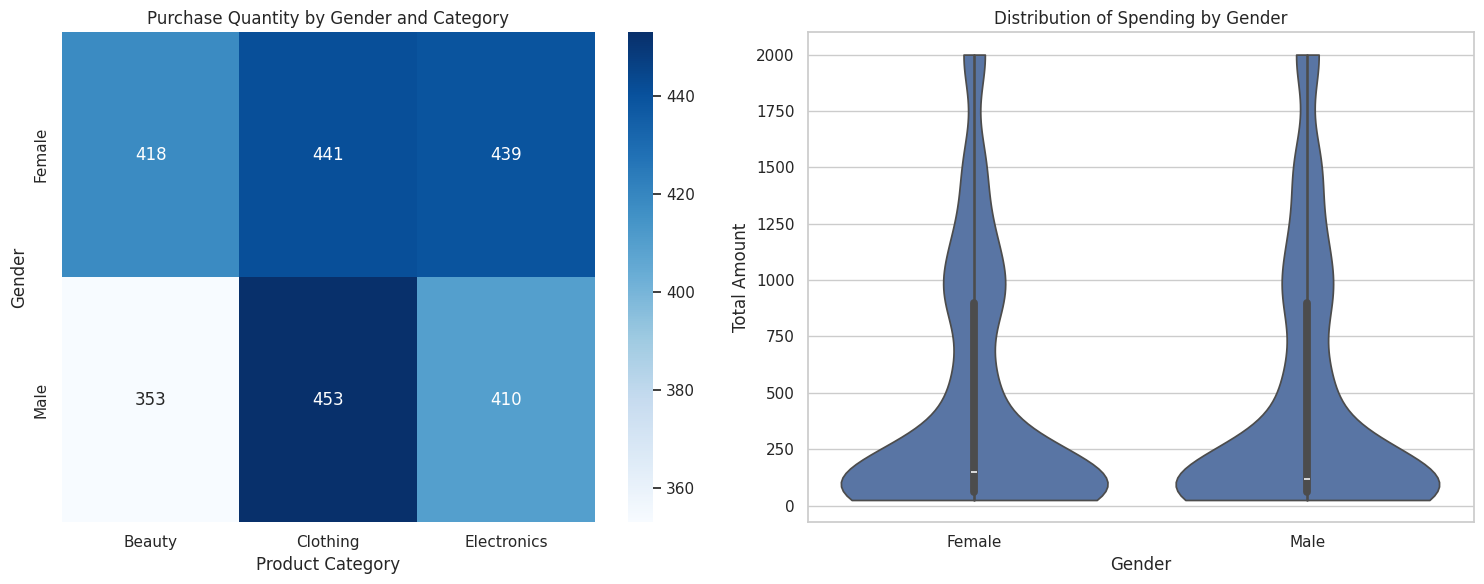

In [85]:
pivot_gender = pd.pivot_table(     # Heatmap Data
    df,
    values='Quantity',
    index='Gender',
    columns='Product Category',
    aggfunc='sum',
    fill_value=0,
    observed=True
)


fig, axes = plt.subplots(1, 2, figsize=(15,6)) # Figure Layout


sns.heatmap(
    pivot_gender,
    annot=True,
    fmt='g',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Purchase Quantity by Gender and Category")
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("Gender")

# -------- Violin Plot --------
sns.violinplot(
    x='Gender',
    y='Total Amount',
    data=df,
    inner='box',        # adds mini boxplot inside
    color='#4C72B0',    # single clean color
    cut=0,              # prevents tails from extending beyond data
    ax=axes[1]
)

axes[1].set_title("Distribution of Spending by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Total Amount")

plt.tight_layout()
plt.show()

The heatmap shows both gende spends more in clothing and least in beauty espicially for males.

The violin plot shows that spending distributions for male and female customers are nearly identical in shape, spread, and density, indicating similar purchasing behavior across genders.
Both groups display a high concentration of lower transaction values with a long upper tail extending toward higher amounts, confirming a right-skewed distribution for each gender.
From a business perspective, this suggests that gender does not significantly influence spending patterns, and therefore marketing strategies should prioritize behavioral or product-based segmentation rather than demographic targeting.

**Age distribution**

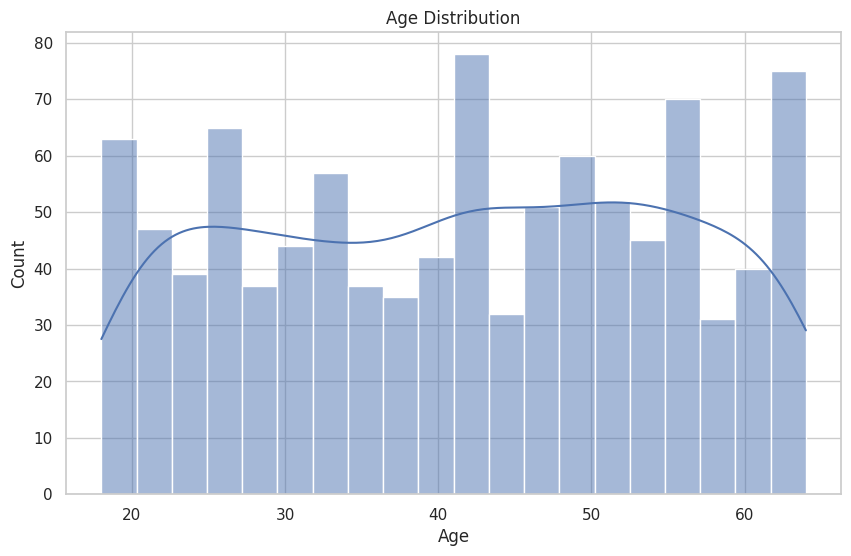

In [ ]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

The histogram shows that customer ages range from approximately 18 to 64 years, with a relatively even distribution across age groups and no strong concentration in a single bracket.
The smooth density curve suggests a fairly balanced demographic spread, with a slight increase in frequency around the 40–55 age range, indicating moderate representation of middle-aged customers.
From a business perspective, this broad age distribution implies that the company appeals to a diverse adult market, and marketing strategies should remain inclusive rather than heavily targeting a narrow age segment.

**Purchase by age group and category**

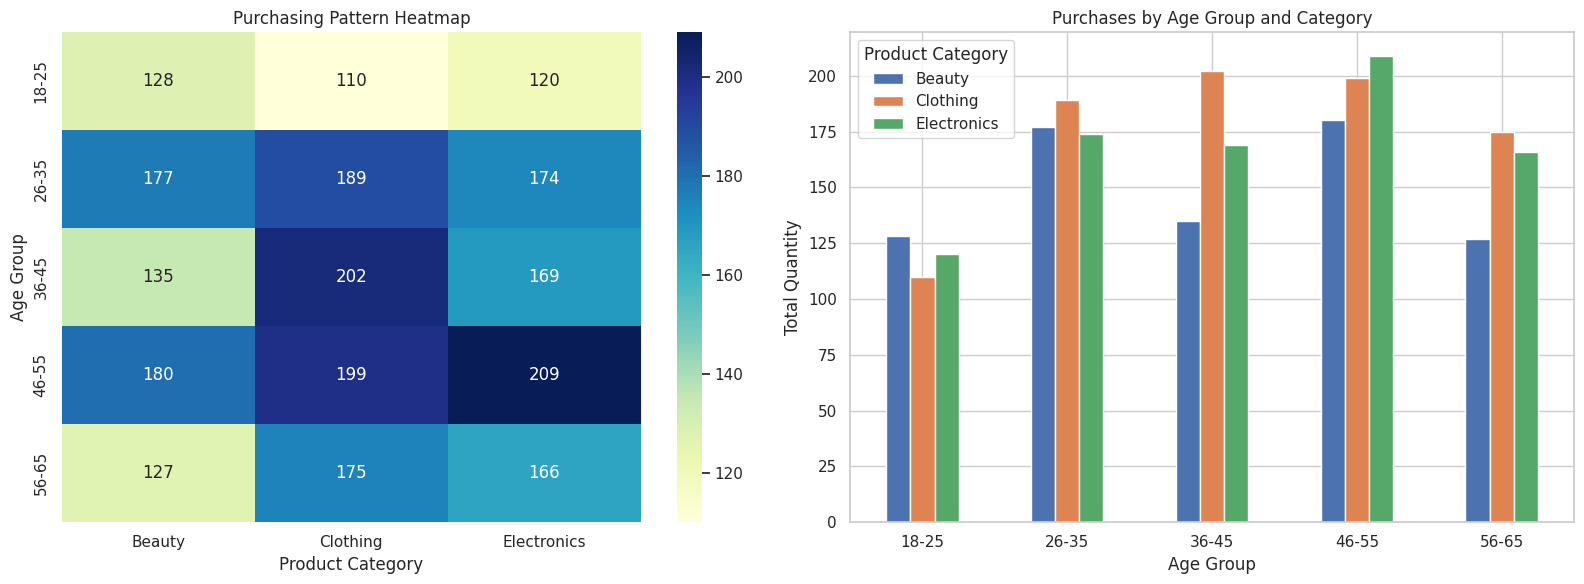

In [81]:
# Creating Age Groups

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

#plotting pivot table
pivot = pd.pivot_table(
    df,
    values='Quantity',
    index='Age_Group',
    columns='Product Category',
    aggfunc='sum',
    fill_value=0,
    observed=True
)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# -------- HEATMAP --------
sns.heatmap(
    pivot,
    annot=True,
    fmt='g',
    cmap='YlGnBu',
    ax=axes[0]
)
axes[0].set_title("Purchasing Pattern Heatmap")
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("Age Group")

# -------- BAR CHART --------
pivot.plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title("Purchases by Age Group and Category")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Total Quantity")
axes[1].tick_params(axis='x', rotation=0)

# -------------------------
plt.tight_layout()
plt.show()

The plot focuses on purchases by age group and category

# Transformation

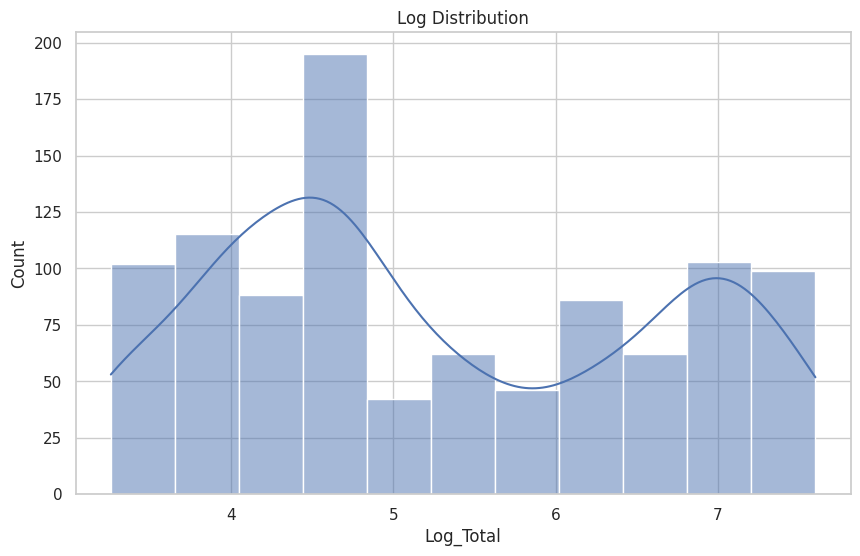

In [ ]:

df['Log_Total'] = np.log1p(df['Total Amount'])

sns.histplot(df['Log_Total'], kde=True)
plt.title("Log Distribution")
plt.show()

The log-transformed distribution shows a more symmetric and stabilized shape compared to the original transaction values, indicating that the logarithmic transformation successfully reduced skewness caused by high-value purchases.
The smoother density curve and reduced spread demonstrate that extreme values now exert less influence on the distribution, making the data more suitable for statistical modeling techniques that assume approximate normality.
From a business perspective, this transformation improves analytical reliability by allowing more accurate comparisons of customer spending patterns and enhancing the performance of predictive models built on transaction data.

# Encoding

In [ ]:
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
df['Category_Encoded'] = le.fit_transform(df['Product Category'])

Label encoding converts categorical variables such as Gender and Product Category into numerical form, enabling their use in machine learning algorithms that require numeric inputs.
Each unique category is assigned an integer value, preserving distinct class identities while preparing the dataset for modeling.

# Feature Importance


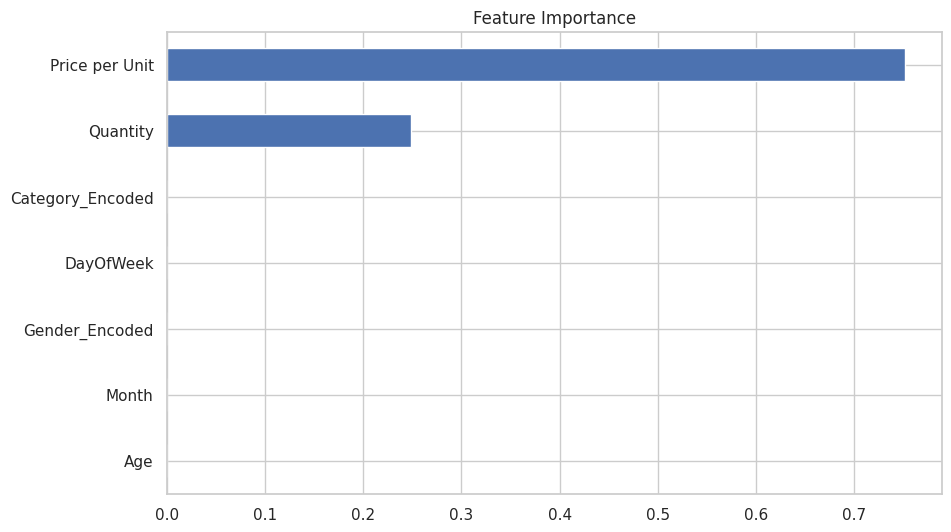

In [ ]:
features = [
    'Age','Quantity','Price per Unit',
    'Month','DayOfWeek',
    'Gender_Encoded','Category_Encoded'
]

X = df[features]
y = df['Total Amount']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestRegressor()
model.fit(X_train,y_train)

pd.Series(model.feature_importances_, index=features)\
.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

The feature importance plot indicates that Price per Unit is the dominant predictor, contributing approximately 75–80% of the model’s explanatory power, confirming that pricing is the primary driver of transaction value.
Quantity contributes moderately (around 20–25%), while demographic and temporal variables such as Age, Month, Gender, and DayOfWeek have minimal predictive influence.
From a business perspective, this suggests that revenue performance is largely determined by pricing strategy and product value positioning, whereas customer demographics and timing factors play a comparatively minor role in predicting transaction amounts.

  **Price elasticity analysis**

In [ ]:
price_change = df['Price per Unit'].pct_change()
qty_change = df['Quantity'].pct_change()

elasticity = (qty_change / price_change).replace([np.inf,-np.inf],np.nan).mean()

print("Approx Price Elasticity:", elasticity)

Approx Price Elasticity: -0.1560308753439734


The estimated price elasticity is −0.156, meaning that a 1% increase in price leads to only about a 0.16% decrease in quantity demanded.

Because the absolute value is less than 1, demand is inelastic, means that customers are not highly sensitive to price changes and revenue may increase with moderate price increases.

# Insight Tables

In [ ]:
df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


The table identifies the top 10 customers ranked by total spending, with each listed customer having a total purchase value of 2000, indicating that they represent the highest-value transactions in the dataset.
The identical totals suggest these customers achieved top status through single high-value purchases rather than frequent transactions.
From a business perspective, these high-spending individuals represent premium customers who contribute disproportionately to revenue and should be prioritized for retention strategies, personalized promotions, and loyalty programs.


**BUSINESS INSIGHTS SUPPORTING DECISION-MAKING**


---


1. Pricing Strategy is the primary revenue driver. Correlation and feature-importance results show that Price per Unit is the strongest predictor of Total Amount, far outweighing demographic or temporal variables.

Decision Implication:
Revenue growth is most sensitive to pricing decisions rather than customer characteristics.

**Action**:
- Optimize pricing tiers
- Introduce premium product lines
- Use price-based promotions rather than demographic targeting


2. High-Value Customers Contribute Disproportionately to Revenue
Top customers recorded the highest total purchase value through large individual transactions.

Decision Implication:
A small segment of customers generates a large share of revenue.

**Action**:
- Implement VIP or loyalty programs
- Offer personalized incentives to high spenders
- Prioritize retention over acquisition for these customers


3. Demand Is Stable but Shows Seasonal Peaks
Monthly trend analysis revealed clear fluctuations with noticeable peak and slow periods.

Decision Implication:
Sales follow seasonal patterns rather than random variation.

**Action:**
- Increase inventory before peak months
- Schedule promotions during slow months
- Align staffing with expected demand


4. Weekly Sales Patterns Suggest Operational Optimization Opportunities
Sales vary across days of the week, with some days consistently outperforming others.

Decision Implication:
Customer purchasing behavior depends on weekday timing.

**Action:**
- Schedule marketing campaigns on high-performing days
- Reduce staffing or operating costs on slower days
- Launch flash sales during low-traffic periods


5. Product Portfolio Is Well Diversified
Sales across product categories are relatively balanced.

Decision Implication:
Revenue is not dependent on a single product line, reducing business risk.

**Action:**
- Maintain multi-category product strategy
- Invest evenly in product development
- Avoid over-reliance on one category


6. Customer Demographics Are Weak Predictors of Spending
Gender and age show minimal influence on transaction value.

Decision Implication:
Traditional demographic segmentation is less useful.

**Action:**
- Shift toward behavioral segmentation
- Personalize recommendations based on purchase history
- Use spending patterns rather than demographic targeting


7. Sales Distribution Shows Many Small Purchases and Few Large Ones
The right-skewed transaction distribution indicates frequent low-value purchases and occasional large purchases.

Decision Implication:
Revenue stability depends on both everyday buyers and high spenders.

**Action:**
- Maintain entry-level products to attract frequent buyers
- Offer premium options for high-value transactions






